In [3]:
import geopandas as gpd
import pandas as pd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *
import osmnx as ox
import os
import ast

In [4]:
# %matplotlib widget

In [5]:
list_districts = ["Barcelona", "Ciutat Vella", "Eixample", "Sants–Montjuic", "Les Corts", "Sarria-Sant Gervasi", "Gracia", "Horta-Guinardo", "Nou Barris", "Sant Andreu", "Sant Marti"]
graph_dict={}
graph_type = "bike" #walk or bike
print("graph_type:",graph_type)
os.makedirs("graphs",exist_ok=True)
for district in list_districts:
    filepath = "graphs/"+district+"-"+graph_type+".graphml"
    if not os.path.isfile(filepath):
        print("Downloading ",district,"from Internet")
        graph = ox.graph.graph_from_place(district + " ,Barcelona, Spain", network_type=graph_type)
        ox.save_graphml(G=graph,filepath=filepath)
    else:
        print("Loading",district," from file")
        graph = ox.load_graphml(filepath)
    graph_dict[district] = graph
print("All graphs loaded")
    

graph_type: bike
Loading Barcelona  from file
Loading Ciutat Vella  from file
Loading Eixample  from file
Loading Sants–Montjuic  from file
Loading Les Corts  from file
Loading Sarria-Sant Gervasi  from file
Loading Gracia  from file
Loading Horta-Guinardo  from file
Loading Nou Barris  from file
Loading Sant Andreu  from file
Loading Sant Marti  from file
All graphs loaded


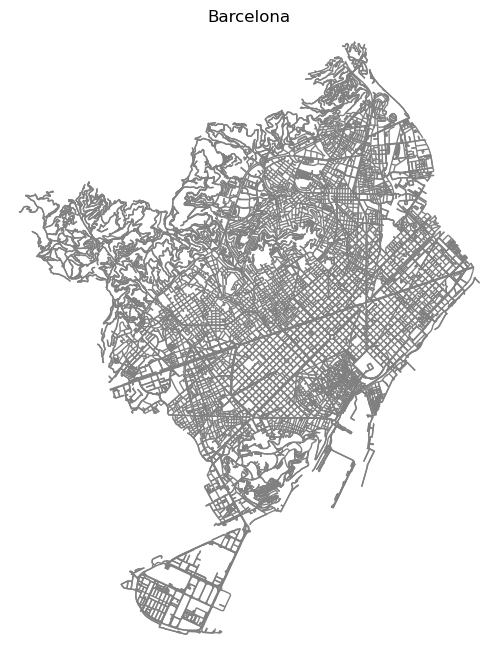

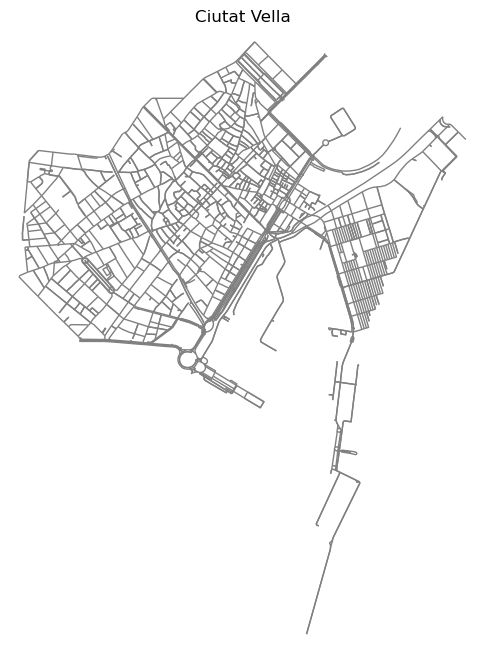

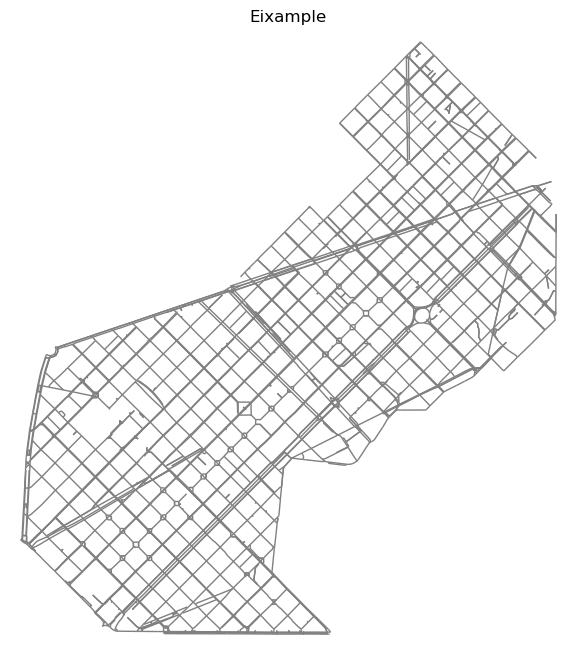

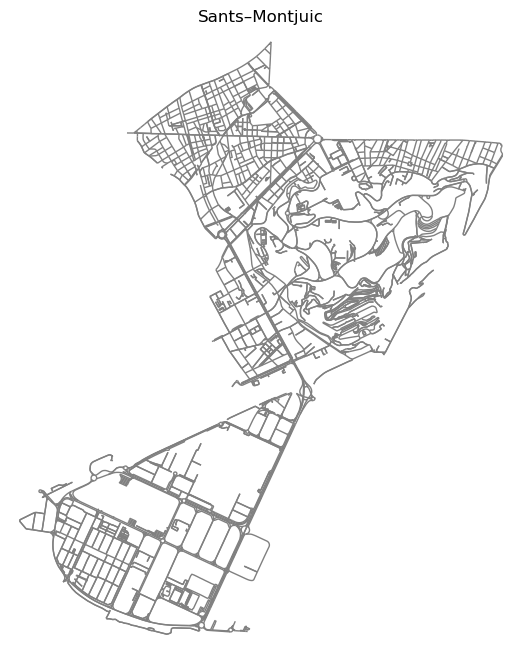

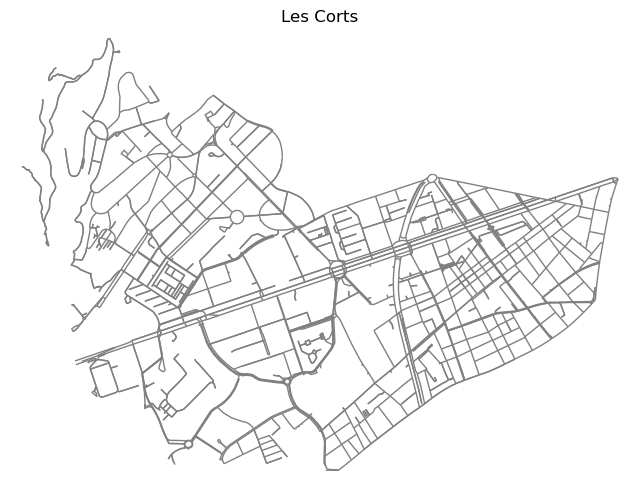

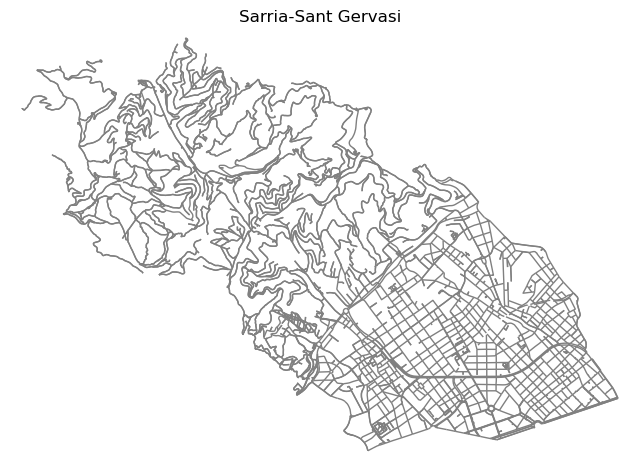

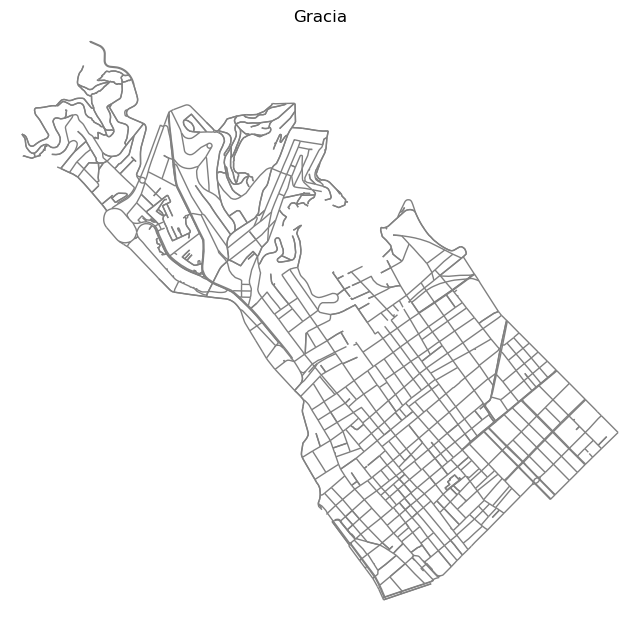

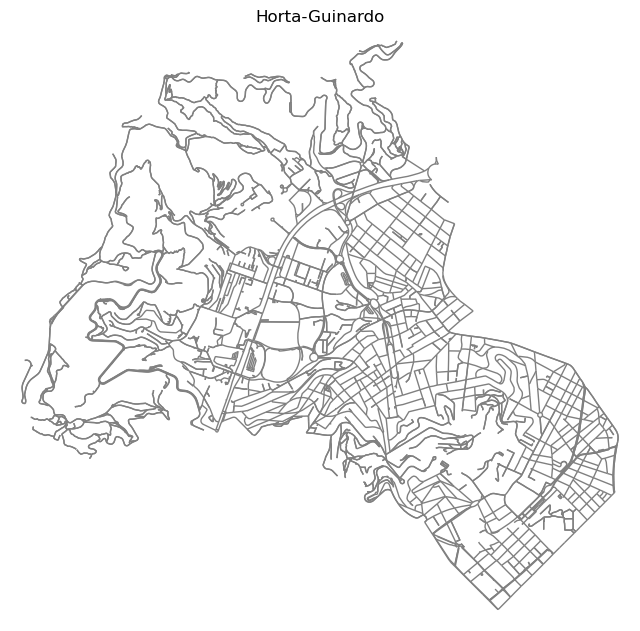

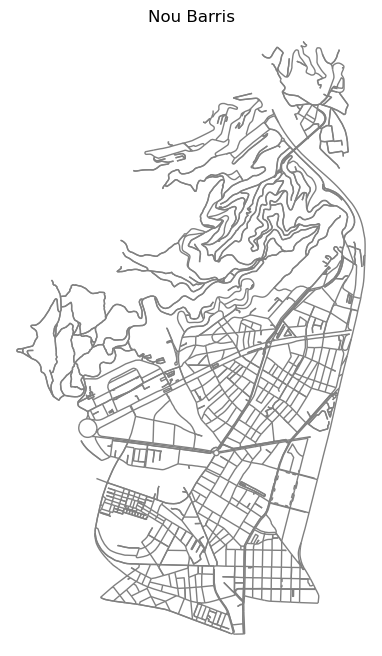

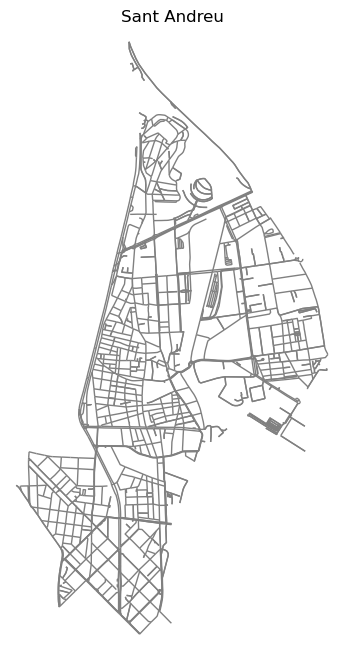

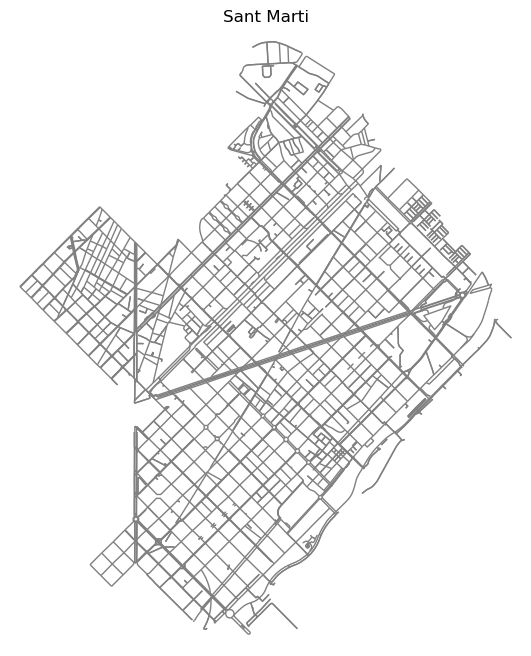

In [6]:
for district in list_districts:
    fig, ax = ox.plot.plot_graph(graph_dict[district],
        edge_color="grey",
        edge_linewidth=1,
        show=False,
        close=False,
        node_zorder=0,
        bgcolor="w")
    ax.set_title(district)

In [7]:
def get_graph_stats(graph):
    G_proj = ox.projection.project_graph(graph)
    nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
    graph_area_m = nodes_proj.union_all().convex_hull.area
    graph_area_m = nodes_proj.union_all().convex_hull.area
    stats = ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)
    return stats

In [8]:
#get_graph_stats(graph_dict["Gracia"])

In [9]:
#get_graph_stats(montlouis)

In [10]:
stats={}
stats_proj={}
for district in list_districts:
    print(district)
    stats[district]=get_graph_stats(graph_dict[district])                          

Barcelona
Ciutat Vella
Eixample
Sants–Montjuic
Les Corts
Sarria-Sant Gervasi
Gracia
Horta-Guinardo
Nou Barris
Sant Andreu
Sant Marti


In [11]:
#example of access to stats of given district
total_street_length = stats["Barcelona"]["edge_length_total"]/1000.
print(total_street_length)
print(stats["Gracia"]["edge_length_total"]/1000.)

2765.510130668057
145.5960676792582


In [12]:
#Example of access to coords of node of 1 district
#node_id = list(graph_dict[district].nodes)[2]
#graph_dict[district].nodes[node_id]

In [13]:
coords_casa = [41.400971,2.160001] #from gmaps
coords_casa_hub = [41.4152636,2.1648925]

In [14]:
#test if lat,lon falls back on right street name
# 
u, v, k = ox.nearest_edges(
    graph_dict["Gracia"], 
    X=coords_casa[1], 
    Y=coords_casa[0]
)
print(u,v,k)
edge_attributes = graph_dict["Gracia"].get_edge_data(u, v, k)
print(edge_attributes.get('name'))

30254379 30333334 0
Carrer de la Fraternitat


In [15]:
def get_all_edge_data(graph, coords_list):

    lats = [c[0] for c in coords_list]
    lons = [c[1] for c in coords_list]

    u_ids, v_ids, keys = ox.nearest_edges(graph, X=lons, Y=lats)

    gdf_edges = ox.graph_to_gdfs(graph, nodes=False, fill_edge_geometry=False)

    results = []
    
    for u, v, k in zip(u_ids, v_ids, keys):
        edge_data = gdf_edges.loc[(u, v, k)]
        
        if type(edge_attributes.get('name')) == str:  
            street_name = edge_attributes.get('name') #usually a string
        else:
            try:
                street_name = edge_attributes.get('name')[0] #edge with coords (41.4049091 2.1738864), (41.4052928 2.1755545) has Provenca and Marina
            except:
                street_name = "Unkwown" # edge from point 867 or 868 from PA has no street name
    #print(type(street_name),street_name)
        
        length = edge_data.get('length', 0)
        
        results.append(((u, v, k), street_name, length))
        
    return results

In [16]:
def save_last_read_gps_point(i,district,user):
    os.makedirs("edges/"+user,exist_ok=True)
    file_list_edges = "edges/last_gpx_point_"+district+"-"+user+".txt"
    with open(file_list_edges, "w") as f:
           f.write(str(i))

In [17]:
def get_coords_date_gpx(user):
    file = glob.glob(f'segments/{user}/*.gpx')[0] 
    gpx_file = open(file, 'r') 
    gpx = gpxpy.parse(gpx_file) 
    coords_gpx = []
    for track in gpx.tracks:
        for s, segment in enumerate(track.segments):
            if (user == 'hubert') & (s in [1, 6]):
                continue
       #     if n_segments and s >= n_segments:
       #         return coords_gpx
            for points in segment.points:
                coords_gpx.append((points.latitude,points.longitude))
    return coords_gpx, points.time


In [18]:
user = "pa"
coords_date_gpx_pa,date_date_last_pa = get_coords_date_gpx(user)
coords_gpx_pa = get_coords_gpx(user)
print(coords_date_gpx_pa)
print(coords_gpx_pa)
print(get_coords_date_gpx(user)[0])
print(get_coords_date_gpx(user)[1])
print(date_date_last_pa)
#print(len(coords_gpx_hubert[0]))
#print(len(coords_gpx_pa))
#coords_gpx_hubert[1]
#print(date_last_hubert)
#print(date_last_pa)


[(41.400205, 2.168775), (41.4003167, 2.16898), (41.400475, 2.1691583), (41.4006067, 2.1693533), (41.4007483, 2.169525), (41.400915, 2.16965), (41.401075, 2.1698217), (41.40122, 2.170015), (41.40138, 2.1702017), (41.401505, 2.1703767), (41.4016317, 2.1705917), (41.4017767, 2.1707667), (41.4019183, 2.1709367), (41.402035, 2.1711667), (41.4021933, 2.17132), (41.402355, 2.1714633), (41.4024817, 2.1716567), (41.4026133, 2.1718467), (41.4027683, 2.1720217), (41.4029233, 2.1722267), (41.4030717, 2.172405), (41.4032, 2.172615), (41.4033333, 2.1727967), (41.4034733, 2.17296), (41.4035633, 2.1731833), (41.4037083, 2.1733717), (41.4038433, 2.173535), (41.40398, 2.173735), (41.40411, 2.1739017), (41.404255, 2.1740533), (41.4043883, 2.174235), (41.4045133, 2.1744167), (41.404665, 2.1745833), (41.4047883, 2.174765), (41.404925, 2.1749517), (41.40508, 2.1751417), (41.4052067, 2.1753317), (41.40535, 2.17551), (41.4054683, 2.175695), (41.405605, 2.1758783), (41.4057717, 2.17606), (41.40592, 2.17623), (

In [19]:
def get_list_edges(graph, coords_gpx, district, user, start=None):
    os.makedirs("edges/"+user,exist_ok=True)
    file_list_edges = "edges/"+user+"/list_edges_"+district+"-"+user+".txt"
    list_edges = []
    if start and os.path.isfile(file_list_edges):
        print("Reading from previous list of edges")
        with open(file_list_edges, "r") as f:
            for line in f:
                if line.strip():
                    list_edges.append(ast.literal_eval(line))
    else:
        print("Starting new list of edges")
        with open(file_list_edges, "w") as f:
            pass 

    idx_start = start if start is not None else 0
    to_process = coords_gpx[idx_start:]
    
    if not to_process:
        return list_edges

    lats = [c[0] for c in to_process]
    lons = [c[1] for c in to_process]

    edges = ox.nearest_edges(graph, X=lons, Y=lats)

    gdf_edges = ox.graph_to_gdfs(graph, nodes=False)

    with open(file_list_edges, "a") as f:
        for u, v, k in edges:
            edge_attributes = gdf_edges.loc[(u, v, k)]
            if type(edge_attributes.get('name')) == str:  
                street_name = edge_attributes.get('name')
            else:
                try:
                    street_name = edge_attributes.get('name')[0]
                except:
                    street_name = "Unkwown"
            length_edge = float(edge_attributes.get('length'))
            edge_data = ((u, v, k), street_name, length_edge)

            if edge_data not in list_edges:
                list_edges.append(edge_data)
                f.write(f"{edge_data}\n")

    save_last_read_gps_point(get_coords_date_gpx(user)[0], district, user)
    
    return list_edges

In [20]:
#save_last_read_gps_point(get_coords_gpx("hubert")[0], "gracia", "hubert")


In [21]:
def load_last_gps_point(district,user):
    try:
        file_list_edges = "edges/"+user+"/last_gpx_point_"+district+"-"+user+".txt"
        with open(file_list_edges, "r") as f:
            return int(f.read())
    except:
        return None

In [22]:
#get_edge_from_coords(graph_dict["Gracia"],[47,1])
#get_list_edges(graph_dict[district],coords_gpx,)
#last_gps_point = load_last_gps_point()
#print(last_gps_point)
#get_list_edges(graph_dict["Barcelona"],coords_gpx,last_gps_point)

In [23]:
#get_coords_gpx("pa")[0]

In [24]:
def generate_list_edges(graph_dict,user):
    list_edges_read={}
    for district in list_districts:
        print(district)
        last_gps_point = load_last_gps_point(district,user)
        print("last_gps_point",last_gps_point)
        coords=get_coords_date_gpx(user)[0]
        list_edges_read[district] = get_list_edges(graph_dict[district],coords,district,user,last_gps_point)
    return list_edges_read

In [25]:
list_edges = {}
list_edges_proj = {}
for user in ["hubert", "pa"]:
    list_edges[user] = generate_list_edges(graph_dict,user)

Barcelona
last_gps_point None
Starting new list of edges
Ciutat Vella
last_gps_point None
Starting new list of edges
Eixample
last_gps_point None
Starting new list of edges
Sants–Montjuic
last_gps_point None
Starting new list of edges
Les Corts
last_gps_point None
Starting new list of edges
Sarria-Sant Gervasi
last_gps_point None
Starting new list of edges
Gracia
last_gps_point None
Starting new list of edges
Horta-Guinardo
last_gps_point None
Starting new list of edges
Nou Barris
last_gps_point None
Starting new list of edges
Sant Andreu
last_gps_point None
Starting new list of edges
Sant Marti
last_gps_point None
Starting new list of edges
Barcelona
last_gps_point None
Starting new list of edges
Ciutat Vella
last_gps_point None
Starting new list of edges
Eixample
last_gps_point None
Starting new list of edges
Sants–Montjuic
last_gps_point None
Starting new list of edges
Les Corts
last_gps_point None
Starting new list of edges
Sarria-Sant Gervasi
last_gps_point None
Starting new list 

In [26]:
#list_edges["hubert"]["Gracia"]

In [27]:
#print(list_edges["hubert"]["Gracia"][0])
#type(list_edges["pa"]["Barcelona"])


In [28]:
def highlight_edges(graph,list_edges,user):
    highlighted_edges_set={}
    highlighted_edges_set[user] = {
        data[0] 
        for data in list_edges[user][district]
    }
    edge_colors = []
    for u, v, k in graph.edges(keys=True):
        edge_id = (u, v, k)
    
        if edge_id in highlighted_edges_set[user]:
            edge_colors.append("red")
        else:
            edge_colors.append("grey")
    return edge_colors

In [29]:
edge_colors={}
for user in ["hubert","pa"]:
    edge_colors[user]={}
    for district in list_districts:
        edge_colors[user][district]= highlight_edges(graph_dict[district],list_edges,user)

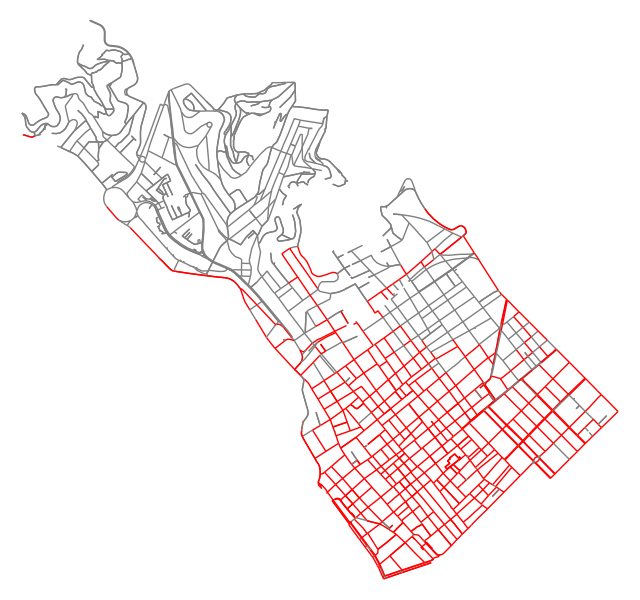

In [30]:
district="Gracia"
user="pa"
edge_colors[district]= highlight_edges(graph_dict[district],list_edges,user)

fig, ax = ox.plot.plot_graph(
            graph_dict[district],
            edge_color=edge_colors[user][district],
            edge_linewidth=1,
            show=False,
            close=False,
            node_zorder=0,
            bgcolor="w"
        )

In [31]:
#type(list_edges)
#n=len(list_edges)
#list_edges[:][0]
#edge_colors
#print(edge_colors["pa"]["Gracia"])

In [32]:
#generalize this and the function below to have a way to plot by user and district and loop over this
def plot_mapped(graph_dict,list_edges,user,district):
    try:
        os.makedirs("plots/"+user)
    except:
        pass
    date=get_coords_date_gpx(user)[1].strftime("%Y-%m-%d")
    print(district)
    edge_colors[district]= highlight_edges(graph,list_edges,user)
    fig, ax = ox.plot.plot_graph(
            graph_dict,
            edge_color=edge_colors[user][district],
            edge_linewidth=1.5,
            show=False,
            close=False,
            node_zorder=0,
            bgcolor="w"
        )
    ax.set_title(district+"-"+user)
    fig.savefig("plots/"+user+"/"+district.replace(" ","_")+"-"+user+"."+date+".jpg", dpi=300, bbox_inches='tight')

hubert
Barcelona
Ciutat Vella
Eixample
Sants–Montjuic
Les Corts
Sarria-Sant Gervasi
Gracia
Horta-Guinardo
Nou Barris
Sant Andreu
Sant Marti
pa
Barcelona
Ciutat Vella
Eixample
Sants–Montjuic
Les Corts
Sarria-Sant Gervasi
Gracia
Horta-Guinardo
Nou Barris
Sant Andreu


/Users/hbretonniere/miniconda3/envs/bikeit_env/lib/python3.13/site-packages/osmnx/plot.py:1055: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize, facecolor=bgcolor, frameon=False)


Sant Marti


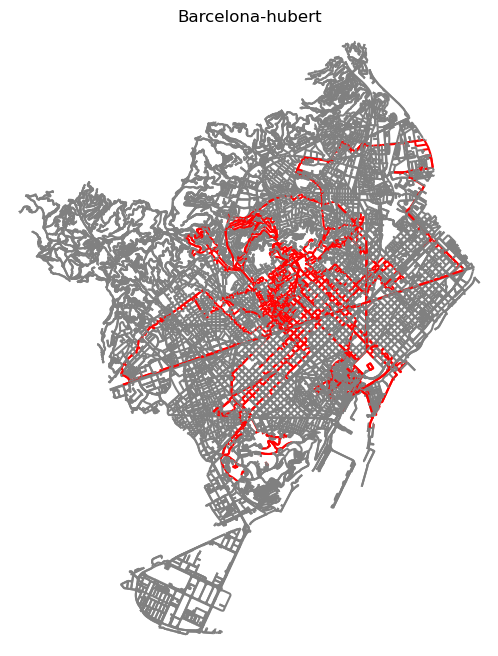

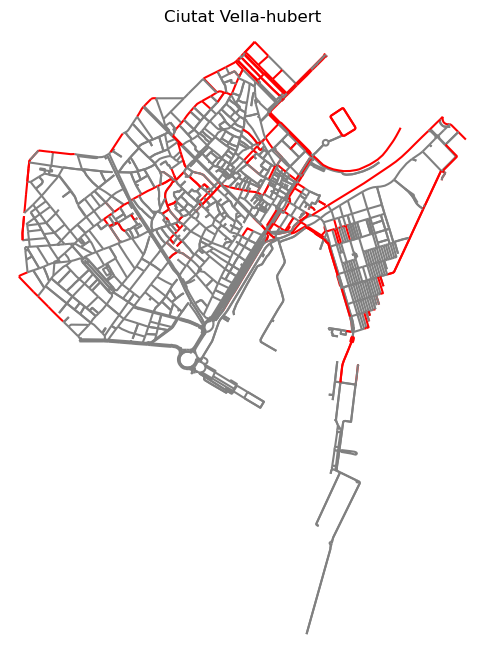

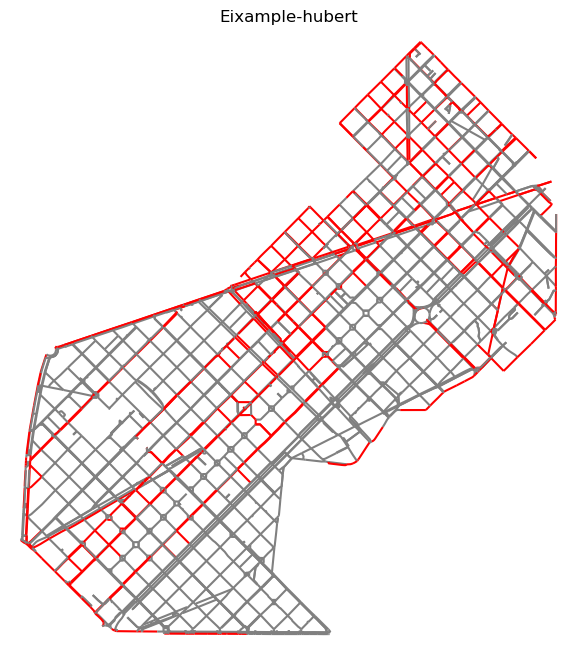

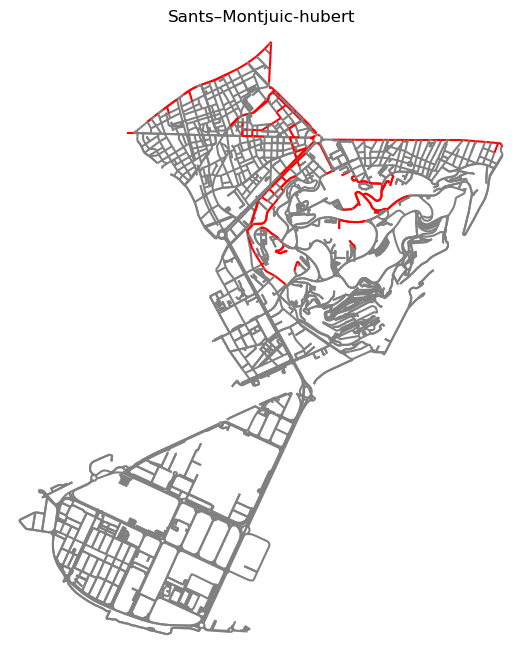

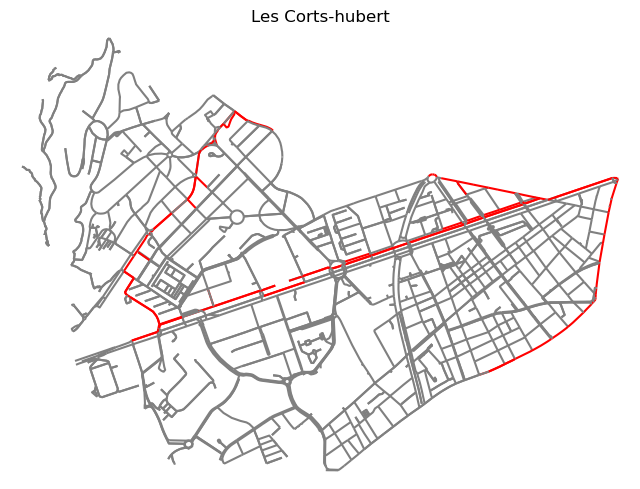

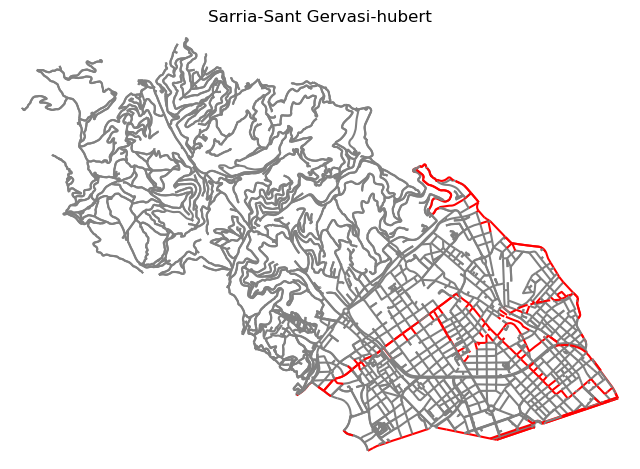

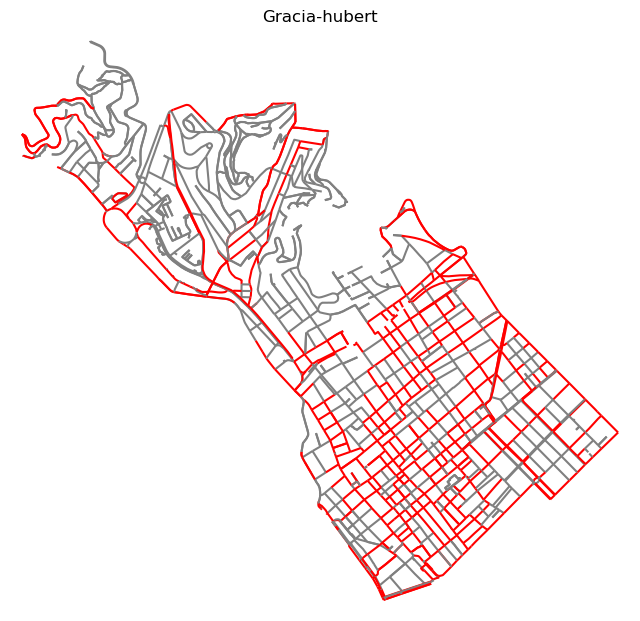

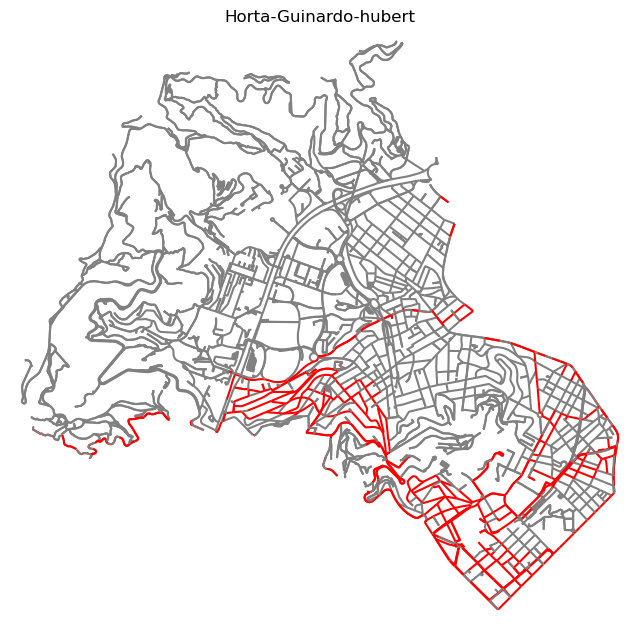

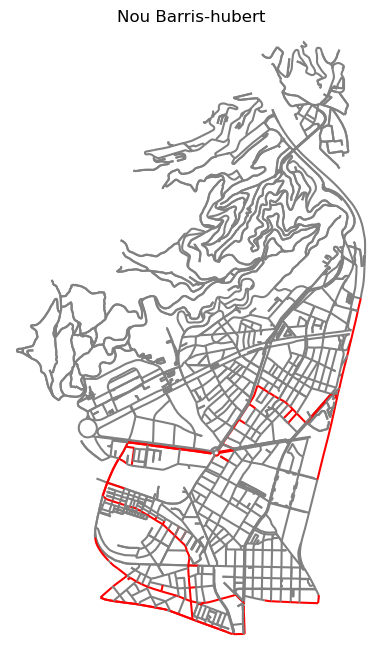

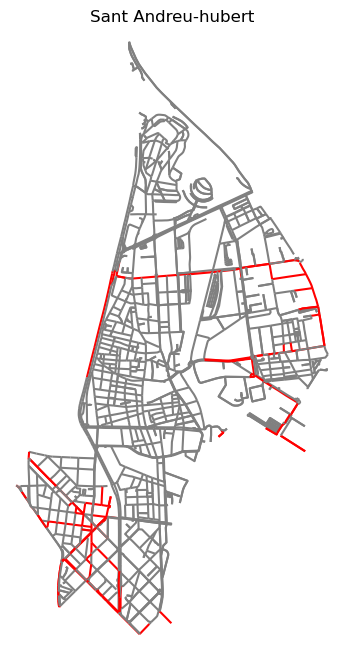

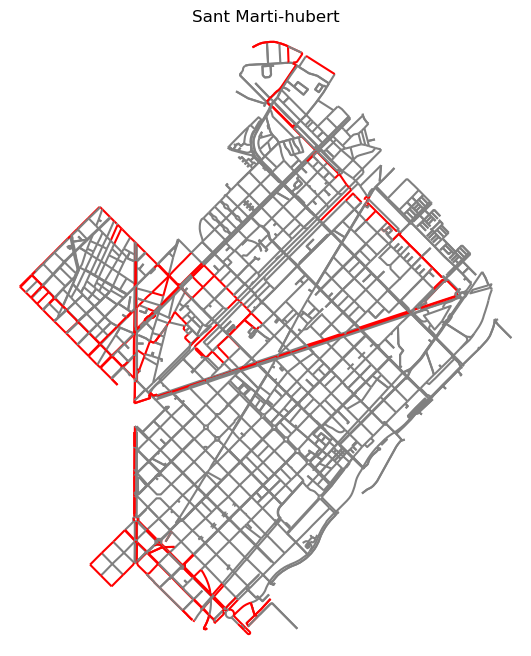

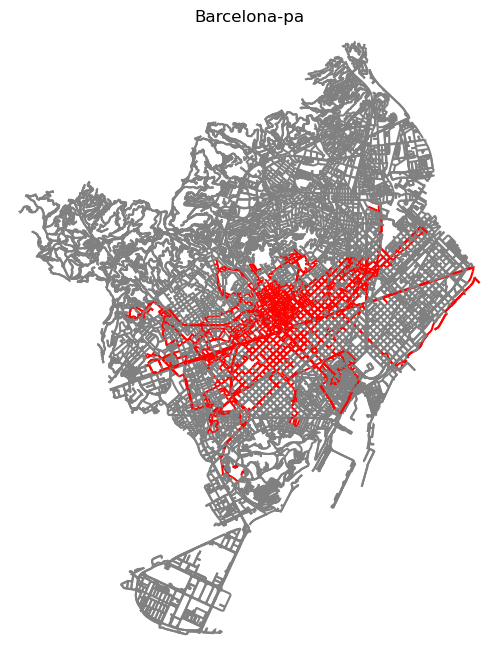

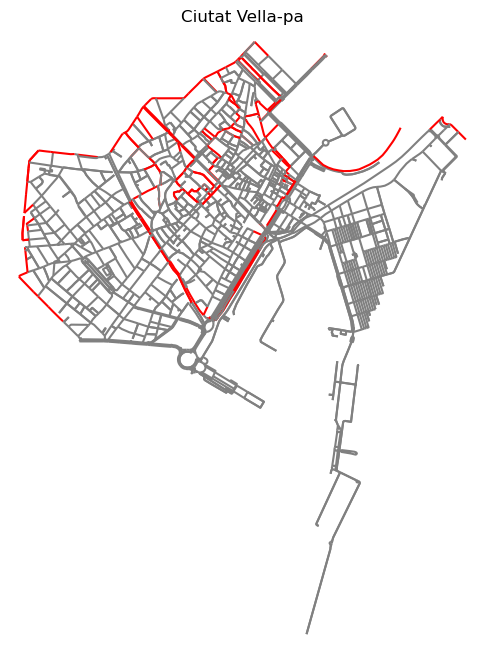

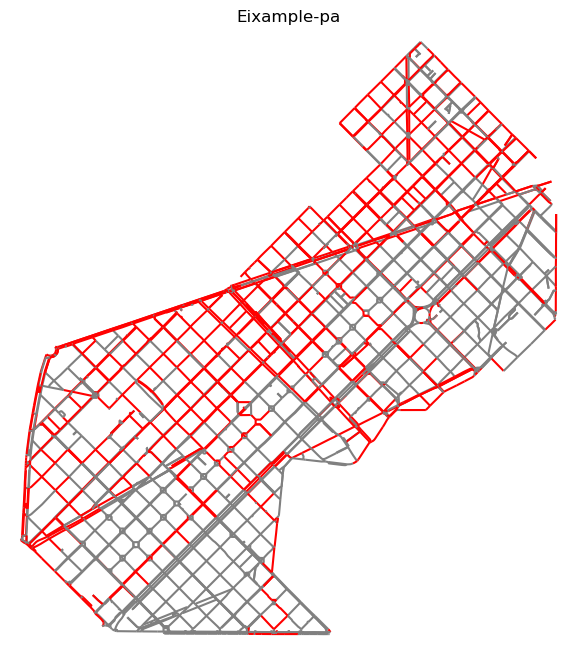

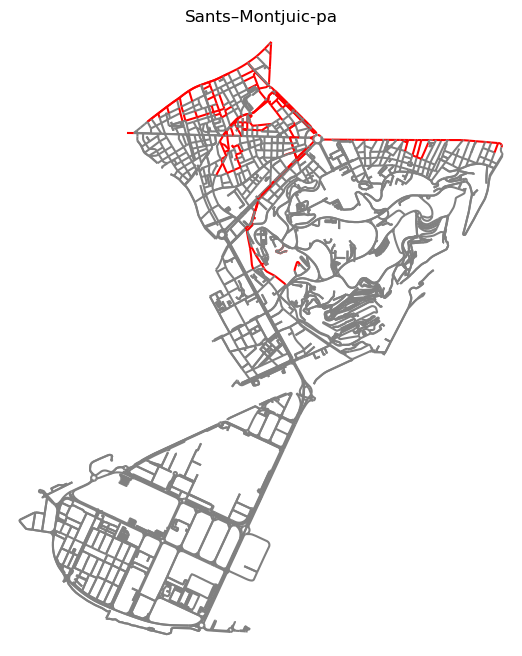

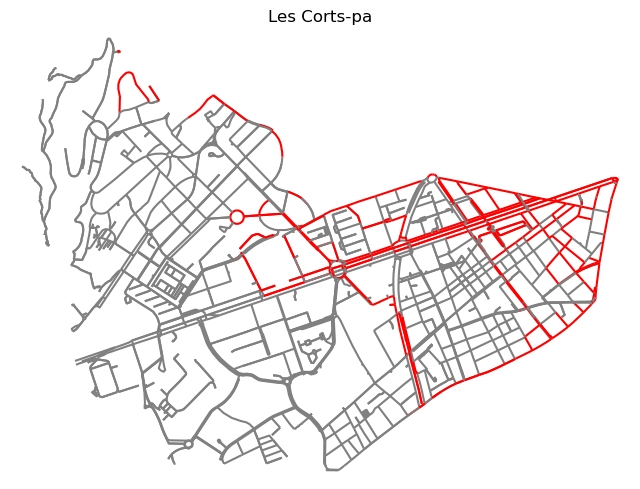

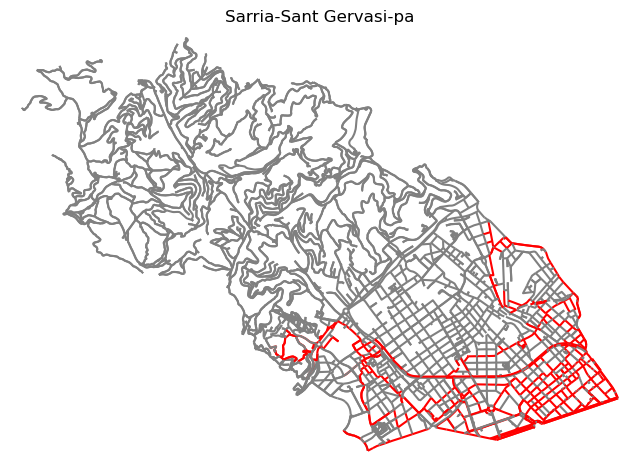

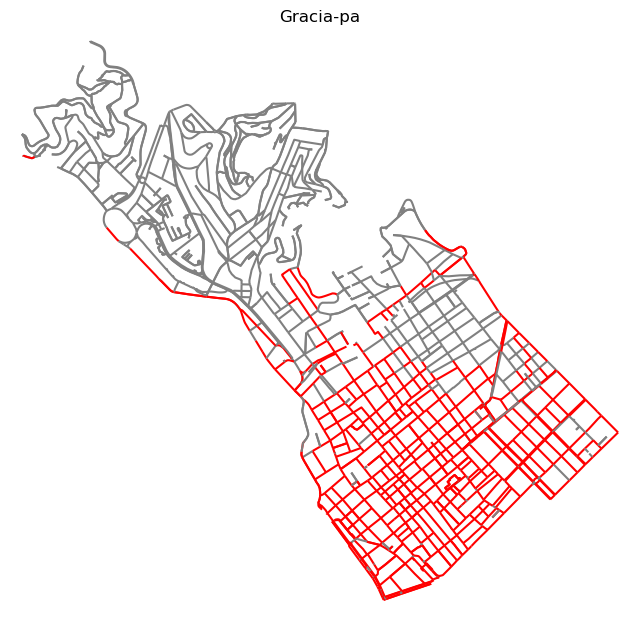

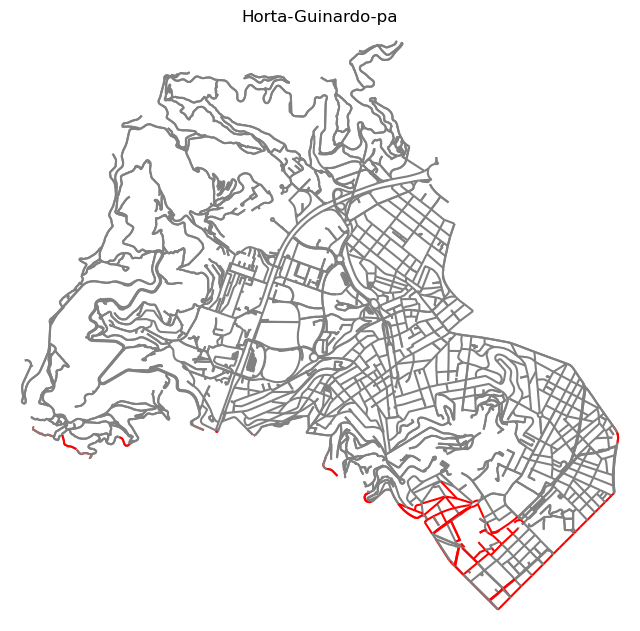

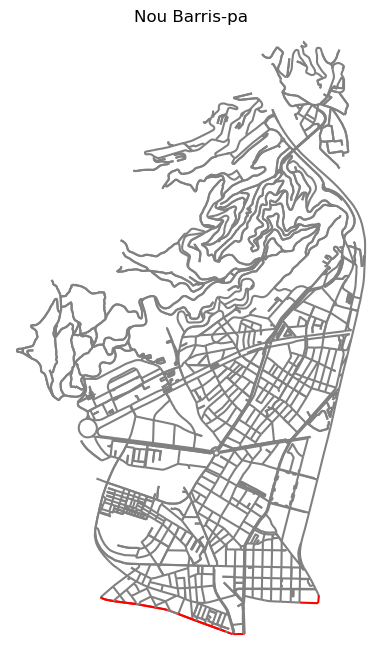

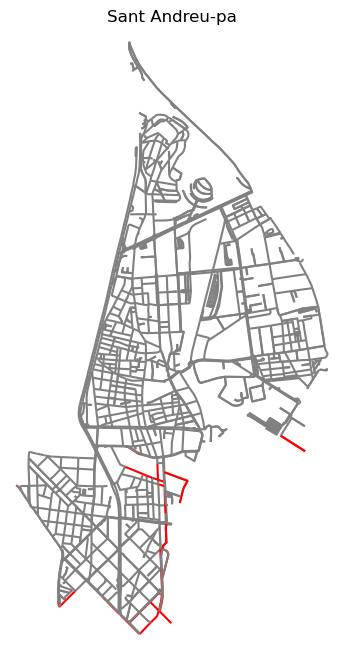

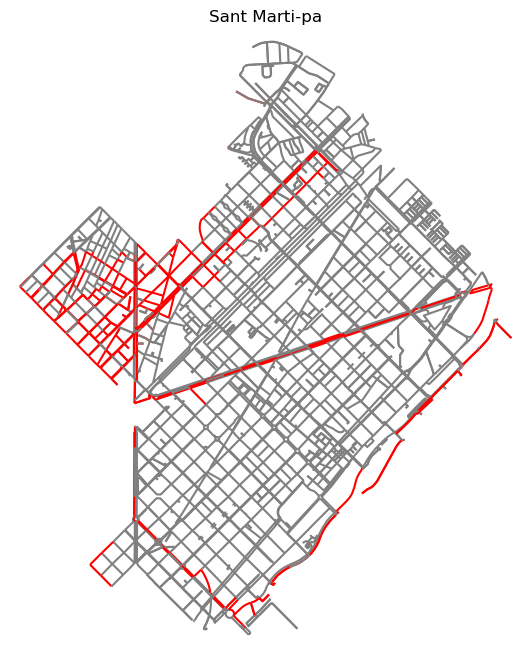

In [33]:
for user in ["hubert","pa"]:
    print(user)
    date=get_coords_date_gpx(user)[1].strftime("%Y-%m-%d")

    for district in list_districts:
        plot_mapped(
            graph_dict[district],
            list_edges,
            user,
            district
        )

Gracia


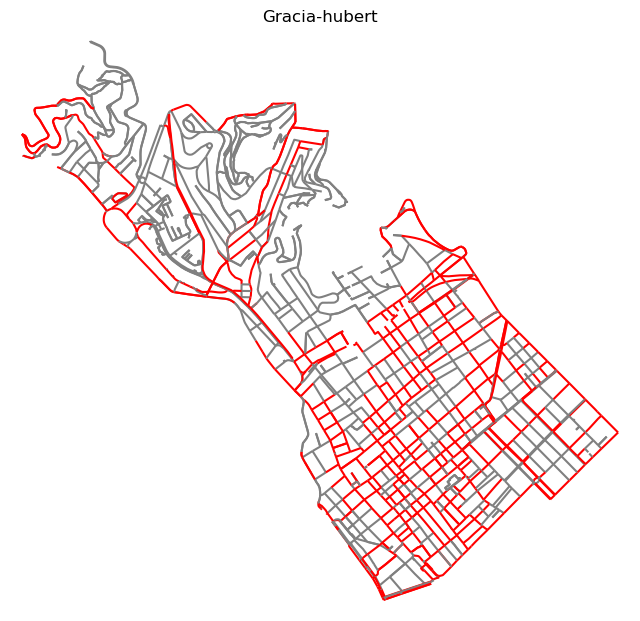

In [34]:
plot_mapped(
            graph_dict["Gracia"],
            list_edges,
            "hubert",
            "Gracia"
        )

Gracia


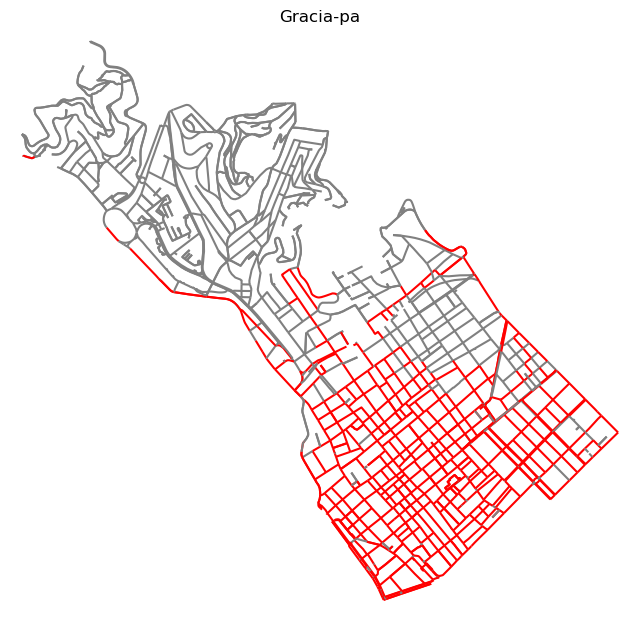

In [35]:
plot_mapped(
            graph_dict["Gracia"],
            list_edges,
            "pa",
            "Gracia"
        )

In [36]:
def get_number_of_mapped_streets(list_edges):
    mapped_street_names = [edge_data[1] for edge_data in list_edges]
    return len(set(mapped_street_names))

In [37]:
#get_number_of_mapped_streets(list_edges["pa"]["Gracia"])

In [38]:
def get_number_of_streets(graph):
    
    unique_street_names_from_G = set()

# Iterate over all edges in the graph, retrieving the attribute data for each edge
# We use keys=False because the u, v, k are not strictly needed for this task,
# only the data dictionary is.
    for _, _, data in graph.edges(data=True):
    # The street name is stored under the key 'name'
        name_entry = data.get('name')
    
    # Check if the 'name' attribute exists
        if name_entry is not None:
            
            if isinstance(name_entry, list):
                # If the value is a list (multiple names), add all individual names to the set
                for name in name_entry:
                    unique_street_names_from_G.add(name)
            elif isinstance(name_entry, str):
            # If the value is a single string, add it to the set
                unique_street_names_from_G.add(name_entry)

# The count of unique street names is the length of the final set
    count_unique_names_G = len(unique_street_names_from_G)
    #print("Total number of streets",count_unique_names_G)
    return count_unique_names_G


In [59]:
def get_final_stats(user,list_edges,graph_dict):
    number_of_mapped_streets = []
    total_number_of_streets = []
    number_of_mapped_segments = []
    total_number_of_segments = []
    mapped_kms = []
    total_street_length = []

    for district in list_districts:
        number_of_mapped_streets.append(get_number_of_mapped_streets(list_edges[user][district]))
        total_number_of_streets.append(get_number_of_streets(graph_dict[district]))
        number_of_mapped_segments.append(len(list_edges[user][district]))
        total_number_of_segments.append(stats[district]["m"])
        mapped_kms.append(sum(edge[2] for edge in list_edges[user][district])/1000)
        total_street_length.append(stats[district]["edge_length_total"]/1000)

    df = pd.DataFrame({
        "districts": list_districts,
        "number of mapped streets": number_of_mapped_streets,
        "total number of streets": total_number_of_streets,
        "percentage street": np.array(number_of_mapped_streets)/np.array(total_number_of_streets)*100,
        "number of mapped segments ": number_of_mapped_segments,
        "total number of segments" : total_number_of_segments, 
        "percentage segments": np.array(number_of_mapped_segments)/np.array(total_number_of_segments)*100,
        "mapped kms": mapped_kms,
        "total street length": total_street_length,
        "percentage km": np.array(mapped_kms)/np.array(total_street_length)*100
    })
    df.set_index('districts')
    return df.style \
    .format(precision=1) \
    .format_index(str.upper, axis=0) \
    .relabel_index(list_districts, axis=0)

In [61]:
get_final_stats("pa",list_edges,graph_dict)

,districts,number of mapped streets,total number of streets,percentage street,number of mapped segments,total number of segments,percentage segments,mapped kms,total street length,percentage km
Barcelona,Barcelona,686,3693,18.6,3764,39247,9.6,321.8,2765.5,11.6
Ciutat Vella,Ciutat Vella,85,566,15.0,225,3420,6.6,18.6,172.6,10.8
Eixample,Eixample,113,155,72.9,1235,4835,25.5,109.9,258.5,42.5
Sants–Montjuic,Sants–Montjuic,84,512,16.4,356,5879,6.1,26.8,431.8,6.2
Les Corts,Les Corts,63,241,26.1,334,2617,12.8,33.4,178.4,18.7
Sarria-Sant Gervasi,Sarria-Sant Gervasi,140,578,24.2,741,5270,14.1,55.5,473.2,11.7
Gracia,Gracia,200,357,56.0,854,2158,39.6,58.4,145.6,40.1
Horta-Guinardo,Horta-Guinardo,39,476,8.2,131,4447,2.9,11.2,356.3,3.1
Nou Barris,Nou Barris,5,356,1.4,36,2985,1.2,2.2,242.7,0.9
Sant Andreu,Sant Andreu,18,324,5.6,57,2880,2.0,5.5,194.8,2.8


In [62]:
get_final_stats("hubert",list_edges,graph_dict)

,districts,number of mapped streets,total number of streets,percentage street,number of mapped segments,total number of segments,percentage segments,mapped kms,total street length,percentage km
Barcelona,Barcelona,662,3693,17.9,3093,39247,7.9,280.8,2765.5,10.2
Ciutat Vella,Ciutat Vella,109,566,19.3,313,3420,9.2,25.1,172.6,14.5
Eixample,Eixample,83,155,53.5,785,4835,16.2,69.5,258.5,26.9
Sants–Montjuic,Sants–Montjuic,51,512,10.0,271,5879,4.6,23.7,431.8,5.5
Les Corts,Les Corts,21,241,8.7,121,2617,4.6,13.6,178.4,7.6
Sarria-Sant Gervasi,Sarria-Sant Gervasi,85,578,14.7,309,5270,5.9,27.9,473.2,5.9
Gracia,Gracia,189,357,52.9,755,2158,35.0,58.2,145.6,40.0
Horta-Guinardo,Horta-Guinardo,135,476,28.4,598,4447,13.4,51.7,356.3,14.5
Nou Barris,Nou Barris,38,356,10.7,154,2985,5.2,13.1,242.7,5.4
Sant Andreu,Sant Andreu,44,324,13.6,213,2880,7.4,19.5,194.8,10.0


In [63]:
print(date)
sorted(glob.glob('stats-'+user+"-"+'*.csv'))[-1]

2026-01-02


IndexError: list index out of range

In [ ]:
def get_final_stats(user,list_edges,graph_dict):
    date=get_coords_date_gpx(user)[1].strftime("%Y-%m-%d")
    stats_file = "stats-"+user+'-'+date+".csv"
    try:
        prev_stats_file = sorted(glob.glob('stats-'+user+'_*.csv'))[-1]
        df_prev = pd.read_csv(prev_stats_file, index_col=0)
        print("loading previous stats")
    except:
        df_prev = []
    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file, index_col=0)
        print("reading from current file")
    else:
        print("creating new stats file")
        number_of_mapped_streets = []
        total_number_of_streets = []
        number_of_mapped_segments = []
        total_number_of_segments = []
        mapped_kms = []
        total_street_length = []

        for district in list_districts:
            number_of_mapped_streets.append(get_number_of_mapped_streets(list_edges[user][district]))
            total_number_of_streets.append(get_number_of_streets(graph_dict[district]))
            number_of_mapped_segments.append(len(list_edges[user][district]))
            total_number_of_segments.append(stats[district]["m"])
            mapped_kms.append(sum(edge[2] for edge in list_edges[user][district])/1000)
            total_street_length.append(stats[district]["edge_length_total"]/1000)

        df = pd.DataFrame({
            "districts": list_districts,
            "number of mapped streets": number_of_mapped_streets,
            "total number of streets": total_number_of_streets,
            "percentage street": np.array(number_of_mapped_streets)/np.array(total_number_of_streets)*100,
            "number of mapped segments ": number_of_mapped_segments,
            "total number of segments" : total_number_of_segments, 
            "percentage segments": np.array(number_of_mapped_segments)/np.array(total_number_of_segments)*100,
            "mapped kms": mapped_kms,
            "total street length": total_street_length,
            "percentage km": np.array(mapped_kms)/np.array(total_street_length)*100
        })
        df.set_index('districts')
        df.to_csv(stats_file)
    return df,df_prev
    


In [65]:
def plot_stats(final_table,previous_table):
    if isinstance(previous_table, pd.DataFrame) and not previous_table.empty:
        print("previous")
        diff = np.abs(final_table.subtract(previous_table, fill_value=0))
    
        display_cols = []
        new_data = {}

        for col in final_table.columns:
            new_data[col] = final_table[col]
            display_cols.append(col)
        
            if (diff[col] != 0).any():
                delta_col_name = "diff "+ col
                new_data[delta_col_name] = diff[col]
                display_cols.append(delta_col_name)

            df_display = pd.DataFrame(new_data, index=final_table.index)[display_cols]
    else:
        df_display = final_table
        print("no previous")
    return df_display.style \
        .format(precision=1) \
        .format_index(str.upper, axis=0) \
        .relabel_index(list_districts, axis=0) \
    .apply(lambda x: ['color: green; font-weight: bold' if 'diff' in x.name else '' 
                      for val in x], axis=0)

In [66]:
user = 'hubert'
# user = 'pa'

In [67]:
final_table,previous_table = get_final_stats(user,list_edges,graph_dict)
plot_stats(final_table,previous_table)

creating new stats file
no previous


,districts,number of mapped streets,total number of streets,percentage street,number of mapped segments,total number of segments,percentage segments,mapped kms,total street length,percentage km
Barcelona,Barcelona,662,3693,17.9,3093,39247,7.9,280.8,2765.5,10.2
Ciutat Vella,Ciutat Vella,109,566,19.3,313,3420,9.2,25.1,172.6,14.5
Eixample,Eixample,83,155,53.5,785,4835,16.2,69.5,258.5,26.9
Sants–Montjuic,Sants–Montjuic,51,512,10.0,271,5879,4.6,23.7,431.8,5.5
Les Corts,Les Corts,21,241,8.7,121,2617,4.6,13.6,178.4,7.6
Sarria-Sant Gervasi,Sarria-Sant Gervasi,85,578,14.7,309,5270,5.9,27.9,473.2,5.9
Gracia,Gracia,189,357,52.9,755,2158,35.0,58.2,145.6,40.0
Horta-Guinardo,Horta-Guinardo,135,476,28.4,598,4447,13.4,51.7,356.3,14.5
Nou Barris,Nou Barris,38,356,10.7,154,2985,5.2,13.1,242.7,5.4
Sant Andreu,Sant Andreu,44,324,13.6,213,2880,7.4,19.5,194.8,10.0


In [68]:

final_table

,districts,number of mapped streets,total number of streets,percentage street,number of mapped segments,total number of segments,percentage segments,mapped kms,total street length,percentage km
0,Barcelona,662,3693,17.925806,3093,39247,7.880857,280.782988,2765.510131,10.153027
1,Ciutat Vella,109,566,19.257951,313,3420,9.152047,25.079525,172.566181,14.533279
2,Eixample,83,155,53.548387,785,4835,16.235781,69.511964,258.450165,26.895693
3,Sants–Montjuic,51,512,9.960938,271,5879,4.609627,23.695646,431.752485,5.488248
4,Les Corts,21,241,8.713693,121,2617,4.623615,13.568843,178.378254,7.606781
5,Sarria-Sant Gervasi,85,578,14.705882,309,5270,5.863378,27.900328,473.228611,5.895740
6,Gracia,189,357,52.941176,755,2158,34.986098,58.208069,145.596068,39.979149
7,Horta-Guinardo,135,476,28.361345,598,4447,13.447268,51.661243,356.306924,14.499085
8,Nou Barris,38,356,10.674157,154,2985,5.159129,13.143583,242.701649,5.415531
9,Sant Andreu,44,324,13.580247,213,2880,7.395833,19.538929,194.811646,10.029651
